In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from ultralytics import YOLO

In [2]:


def best_edge_fix(img_path):
    # Read image
    img = img_path
    
    # Convert to gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Improve contrast (important for your image)
    gray = cv2.equalizeHist(gray)

    # 2. Remove noise but keep edges
    gray = cv2.bilateralFilter(gray, 9, 75, 75)

    # 3. Morphological gradient (fix weak top edges)
    kernel_grad = np.ones((5, 5), np.uint8)
    grad = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel_grad)

    # 4. Canny edge detection
    edges = cv2.Canny(grad, 60, 160)

    # 5. Extra directional edge (helps top flat region)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_y = cv2.convertScaleAbs(sobel_y)
    edges_y = cv2.Canny(sobel_y, 30, 100)

    # Combine edges
    edges = cv2.bitwise_or(edges, edges_y)

    # 6. Close gaps (very important)
    kernel_close = np.ones((5, 5), np.uint8)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close, iterations=2)

    # 7. Slight dilation for stronger outline
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)

    return img, gray, grad, edges



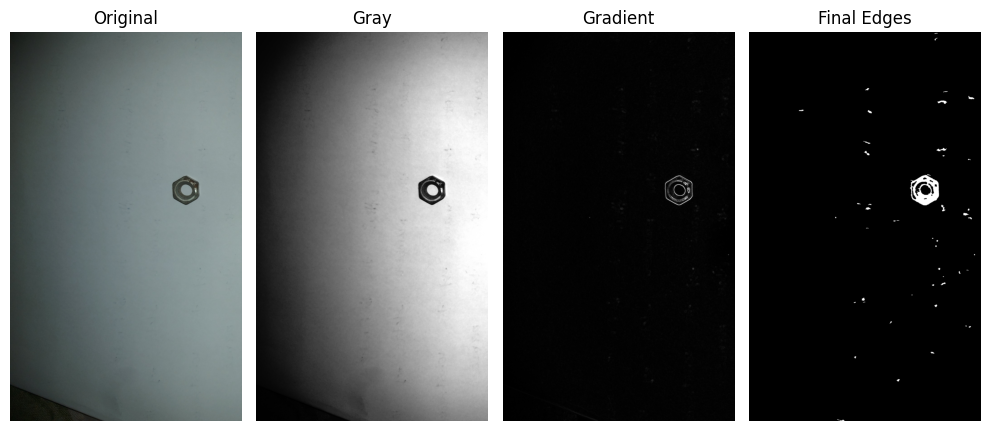

In [3]:
img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\test3\IMG_20260413_123042.jpg"
# img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\gen\tpr.png"
# img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\testing1\IMG_20260413_123010.jpg"
img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\New folder\20260514_190440.jpg.jpeg"
img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\New folder\nut3.jpg"
img = cv2.imread(img)
# img=cv2.resize(img,(640,630))
img, gray, grad, edges = best_edge_fix(img)


# 🔽 DISPLAY
plt.figure(figsize=(10,6))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Gray")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title("Gradient")
plt.imshow(grad, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title("Final Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
cv2.imwrite("f1.jpg",grad)
cv2.imwrite("f2.jpg",gray)

True

In [5]:
import cv2
import numpy as np

def get_outer_contour(edge_img, gray_img):

    # Binary
    _, edge = cv2.threshold(
        edge_img,
        15,
        255,
        cv2.THRESH_BINARY
    )

    # Close gaps in edge
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5,5)
    )

    edge = cv2.morphologyEx(
        edge,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Fill from contour
    contours, _ = cv2.findContours(
        edge,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if not contours:
        return None, None, gray_img

    cnt = max(contours, key=cv2.contourArea)

    # Fill object
    mask = np.zeros_like(edge)

    cv2.drawContours(
        mask,
        [cnt],
        -1,
        255,
        -1
    )

    # Smooth mask and remove side artifacts
    kernel2 = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (11,11)
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel2
    )

    # Extract contour again from cleaned mask
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    cnt = max(contours, key=cv2.contourArea)

    out = cv2.cvtColor(
        gray_img,
        cv2.COLOR_GRAY2BGR
    )

    cv2.drawContours(
        out,
        [cnt],
        -1,
        (0,255,0),
        2
    )

    return cnt, mask, out

True

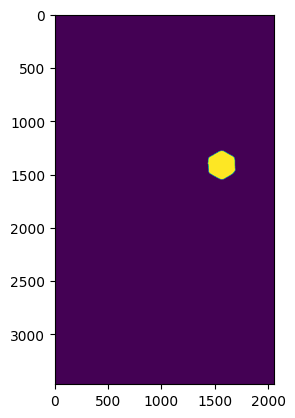

In [6]:
hexagon, mask, result = get_outer_contour(grad, gray)
# re,rt,uu=draw_nut_outline(gray)
plt.imshow(mask)
cv2.imwrite("wasted.png",mask)

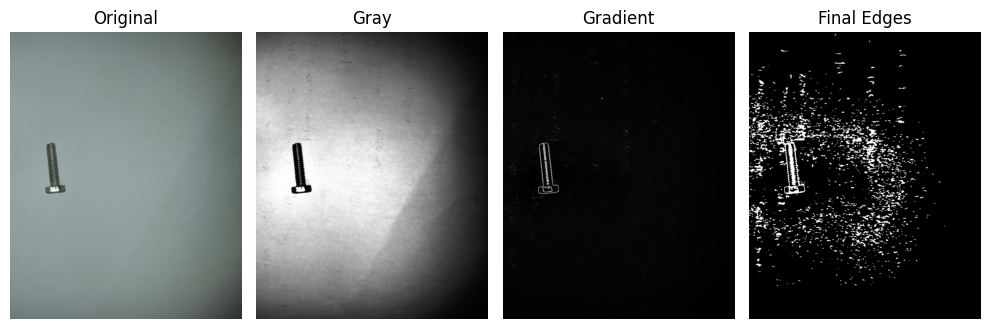

In [7]:
img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\test3\IMG_20260413_123042.jpg"
# img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\gen\tpr.png"
# img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\testing1\IMG_20260413_123010.jpg"
img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\New folder\20260514_190440.jpg.jpeg"
img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\New folder\bolt3.jpg"
img = cv2.imread(img)
# img=cv2.resize(img,(640,630))
img, gray, grad, edges = best_edge_fix(img)


# 🔽 DISPLAY
plt.figure(figsize=(10,6))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Gray")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title("Gradient")
plt.imshow(grad, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title("Final Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
cv2.imwrite("f.jpg",grad)

True

In [9]:



model = YOLO(r"C:\python\computer_vision\Image-based-dimension-measurement-\model\yolo_bolt_nut_seg_best.pt")



In [10]:
def get_yolo_mask(image, expand_percent=5):
    """
    Returns combined YOLO segmentation mask
    with expanded mask size
    """

    # Predict
    results = model.predict(image, verbose=False)

    h, w = image.shape[:2]

    # Empty mask
    final_mask = np.zeros((h, w), dtype=np.uint8)

    # No masks
    if results[0].masks is None:
        return final_mask

    # Combine all masks
    for mask in results[0].masks.data:

        # Tensor -> numpy
        m = mask.cpu().numpy()

        # Resize
        m = cv2.resize(m, (w, h))

        # Binary
        m = (m > 0.5).astype(np.uint8) * 255

        # Merge
        final_mask = cv2.bitwise_or(final_mask, m)

    # -----------------------------
    # Expand mask size
    # -----------------------------
    
    # Kernel size based on image size
    k = int(min(h, w) * (expand_percent / 100))

    # Keep kernel odd and minimum 1
    k = max(1, k)

    kernel = np.ones((k, k), np.uint8)

    # Dilate mask
    final_mask = cv2.dilate(final_mask, kernel, iterations=1)

    return final_mask

In [11]:
def draw_mask(image, mask, color=(0, 255, 0), alpha=0.5):
    """
    Draw mask on image
    """

    # Copy image
    output = image.copy()

    # Create colored mask
    colored_mask = np.zeros_like(image)
    colored_mask[mask > 0] = color

    # Blend
    output = cv2.addWeighted(output, 1, colored_mask, alpha, 0)

    return output

In [12]:
def reconstruct_mask(edge_mask, yolo_mask):
    # -----------------------------
    # Normalize
    # -----------------------------
    edge = edge_mask.astype(np.uint8)
    yolo = yolo_mask.astype(np.uint8)

    # Binary yolo
    yolo_bin = np.where(yolo > 0, 255, 0).astype(np.uint8)

    # Keep soft edge values
    edge_soft = edge.copy()

    # Strong edges only
    edge_bin = np.where(edge > 40, 255, 0).astype(np.uint8)

    # -----------------------------
    # Restrict edges inside YOLO
    # -----------------------------
    edge_inside = cv2.bitwise_and(edge_bin, yolo_bin)

    # -----------------------------
    # Connect small edge gaps
    # -----------------------------
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    connected = cv2.morphologyEx(
        edge_inside,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    # -----------------------------
    # Fill connected regions
    # -----------------------------
    contours, _ = cv2.findContours(
        connected,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    fill = np.zeros_like(edge)

    for c in contours:

        area = cv2.contourArea(c)

        if area > 50:
            cv2.drawContours(
                fill,
                [c],
                -1,
                255,
                -1
            )

    # -----------------------------
    # Merge edge detail + fill
    # -----------------------------
    result = np.maximum(fill, edge_soft)

    # -----------------------------
    # Final constrain to YOLO
    # -----------------------------
    result = cv2.bitwise_and(result, yolo_bin)

    return result

Corners: 6


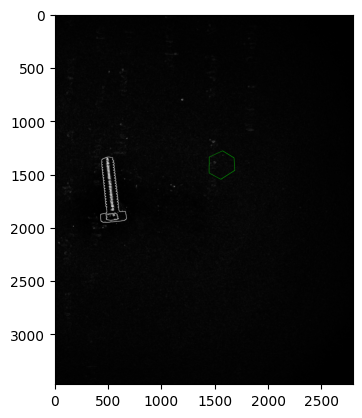

In [13]:

def find_hexagon(mask):

    # Convert varying intensity (50,100,200...) -> binary
    _, binary = cv2.threshold(
        mask, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Connect broken edges
    kernel = np.ones((5,5), np.uint8)
    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    # Get largest object
    cnt = max(contours, key=cv2.contourArea)

    # Smooth shape
    hull = cv2.convexHull(cnt)

    peri = cv2.arcLength(hull, True)

    approx = cv2.approxPolyDP(
        hull,
        0.03 * peri,
        True
    )

    return approx


# Use
hex_cnt = find_hexagon(mask)

result = cv2.cvtColor(grad, cv2.COLOR_GRAY2BGR)

if hex_cnt is not None:
    cv2.drawContours(
        result,
        [hex_cnt],
        -1,
        (0,255,0),
        2
    )

    print("Corners:", len(hex_cnt))
cv2.imwrite("edge.png",result)
plt.imshow(result)

In [14]:
hex=find_hexagon(grad)
# plt.imshow(hex)
hex

array([[[ 505, 1338]],

       [[ 671, 1922]],

       [[ 451, 1954]],

       [[ 436, 1366]]], dtype=int32)

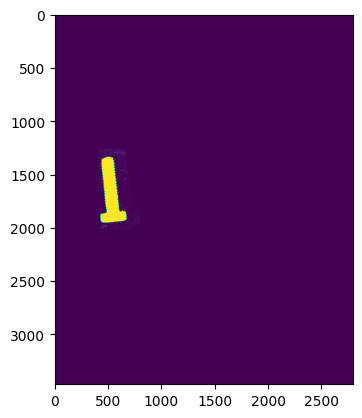

In [15]:
ymask=get_yolo_mask(img)
final_mask = reconstruct_mask(grad, ymask)
cv2.imwrite("new2.png",final_mask)
plt.imshow(final_mask)


In [16]:

def fill_object_from_edges(edge_mask, yolo_mask):
    """
    edge_mask : sharp edge image
    yolo_mask : YOLO segmentation mask

    Returns:
        Filled white object using edges inside YOLO area
    """

    # Binary YOLO mask
    _, yolo_bin = cv2.threshold(yolo_mask, 1, 255, cv2.THRESH_BINARY)

    # Binary edge mask
    _, edge_bin = cv2.threshold(edge_mask, 50, 255, cv2.THRESH_BINARY)

    # Keep only edges inside YOLO mask
    edges_inside = cv2.bitwise_and(edge_bin, yolo_bin)

    # Connect broken edges
    kernel = np.ones((13,13), np.uint8)
    connected = cv2.morphologyEx(edges_inside, cv2.MORPH_CLOSE, kernel)

    # Find contours from connected edges
    contours, _ = cv2.findContours(
        connected,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Create filled mask
    filled = np.zeros_like(edge_mask)

    # Fill contours white
    cv2.drawContours(filled, contours, -1, 255, thickness=cv2.FILLED)

    # Keep only inside YOLO region
    filled = cv2.bitwise_and(filled, yolo_bin)

    return filled


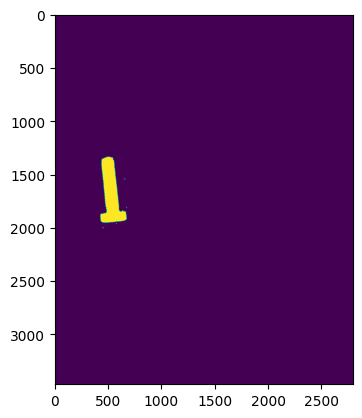

In [17]:
final_mask = fill_object_from_edges(grad, ymask)
plt.imshow(final_mask)